# =============================================
# 1. Wstęp i cel projektu
# =============================================

#Wstęp

Wykorzystując rzeczywiste recenzje filmów z serwisu IMDb zbudowany zostanie model klasyfikujący ich sentyment (pozytywny lub negatywny). Opieramy się na datasecie pochodzącego z serwisu kaggle zawierającym 50 000 recenzji tekstowych oznaczonych etykietami sentymentu, co pozwala zastosować metody uczenia maszynowego do analizy opinii użytkowników w sposób zautomatyzowany.
​

#Cel projektu

Celem jest przygotowanie kompletnego pipeline’u analitycznego: od wczytania i wstępnego przetworzenia tekstu, przez wektoryzację recenzji, aż po zbudowanie i ocenę modelu klasyfikacji sentymentu (Logistic Regression, Naive Bayes, LinearSVC). Na końcu wyniki modelu są zinterpretowane.


# =============================================
# 2. Import bibliotek
# =============================================

In [18]:
# Podstawowe biblioteki do analizy danych
import pandas as pd
import numpy as np

# Wizualizacja danych
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Przetwarzanie tekstu
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Biblioteki do uczenia maszynowego
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, classification_report

# Dodatkowe
import re
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Wszystkie biblioteki zaimportowane pomyślnie!")

Wszystkie biblioteki zaimportowane pomyślnie!


# =============================================
# 3. Załadowanie i wstępna eksploracja danych
# =============================================

Dataset załadowany pomyślnie!
Rozmiar datasetu: (50000, 2)

📊 Pierwsze 5 wierszy:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

📋 Informacje o strukturze:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

🎯 Rozkład sentymentu:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Procentowy udział:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

Statysty

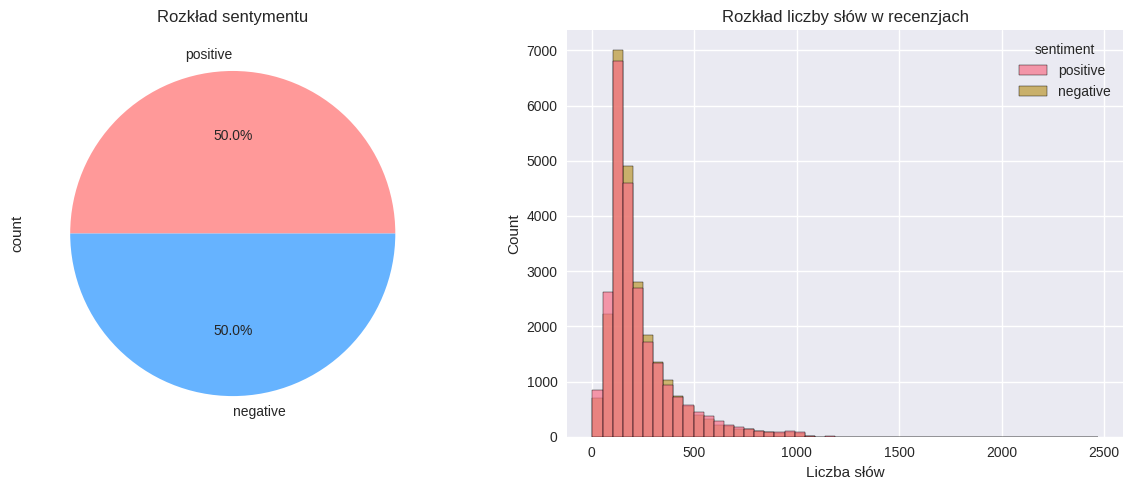


PRZYKŁADOWE RECENZJE:

✅ POZYTYWNA:
One of the other reviewers has mentioned that after watching just 1 Oz episode
you'll be hooked. They are right, as this is exactly what happened with me.<br
/><br />The first thing that struck me about Oz was its brutality and
unflinching scenes of violence, which set in right from the word GO. Trust me,
this is not a show for the faint hearted or timid. This show pulls no punches
with regards to drugs, sex or violence. Its is hardcore, in the classic use of
the word.<br /><br />It is called OZ as that is the nickname given to the Oswald
Maximum Security State Penitentary. It focuses mainly on Emerald City, an
experimental section of the prison where all the cells have glass fronts and
face inwards, so privacy is not high on the agenda. Em City is home to
many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and
more....so scuffles, death stares, dodgy dealings and shady agreements are never
far away.<br /><br />I would say the main

In [19]:
import textwrap

# 3.1. Załadowanie datasetu
df = pd.read_csv('IMDB Dataset.csv')
print("Dataset załadowany pomyślnie!")
print(f"Rozmiar datasetu: {df.shape}")
print()

# 3.2. Pierwsze spojrzenie na dane
print("📊 Pierwsze 5 wierszy:")
print(df.head())
print()

print("📋 Informacje o strukturze:")
print(df.info())
print()

# 3.3. Rozkład klas sentymentu
print("🎯 Rozkład sentymentu:")
print(df['sentiment'].value_counts())
print(f"\nProcentowy udział:")
print(df['sentiment'].value_counts(normalize=True) * 100)
print()

# 3.4. Analiza długości tekstu
df['review_length'] = df['review'].apply(lambda x: len(x))
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print("Statystyki długości recenzji:")
print(df[['review_length', 'word_count']].describe())
print()

# 3.5. Porównanie długości według sentymentu
print("Średnia długość według sentymentu:")
print(df.groupby('sentiment')[['review_length', 'word_count']].mean())
print()

# 3.6. Wizualizacja rozkładu sentymentu
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                   colors=['#ff9999','#66b3ff'])
plt.title('Rozkład sentymentu')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, alpha=0.7)
plt.title('Rozkład liczby słów w recenzjach')
plt.xlabel('Liczba słów')

plt.tight_layout()
plt.show()

# 3.7. Przykładowe recenzje z zawijaniem tekstu
print("\nPRZYKŁADOWE RECENZJE:")
print("\n✅ POZYTYWNA:")
print(textwrap.fill(df[df['sentiment']=='positive']['review'].iloc[0], width=80))
print("\n❌ NEGATYWNA:")
print(textwrap.fill(df[df['sentiment']=='negative']['review'].iloc[0], width=80))


# =============================================
# 4. Czyszczenie tekstu (preprocessing)
# =============================================

Funkcja preprocessingu gotowa!

🔄 Czyszczenie 50k recenzji...
Czyszczenie zakończone!

📊 PORÓWNANIE PRZED/PO:
PRZED:
Of all the films I have seen, this one, The Rage, has got to be one of the worst
yet. The direction, LOGIC, continuity, changes in plot-script and dialog made me
cry out in pain. "How could ANYONE come up with something so crappy"? Gary Busey
is know for his "B" movies, but this is a sure "W" movie. (W=waste).<br /><br
/>Take for example: about two dozen FBI & local law officers surround a trailer
house with a jeep wagoneer. Inside the jeep is MA and is "confused" as to why
all the cops are about. Within seconds a huge gun battle ensues, MA being killed
straight off. The cops blast away at the jeep with gary and company blasting
away at them. The cops fall like dominoes and the jeep with Gary drives around
in circles and are not hit by one single bullet/pellet. MA is killed and gary
seems to not to have noticed-damn that guy is tough. Truly a miracle, not since
the six-s

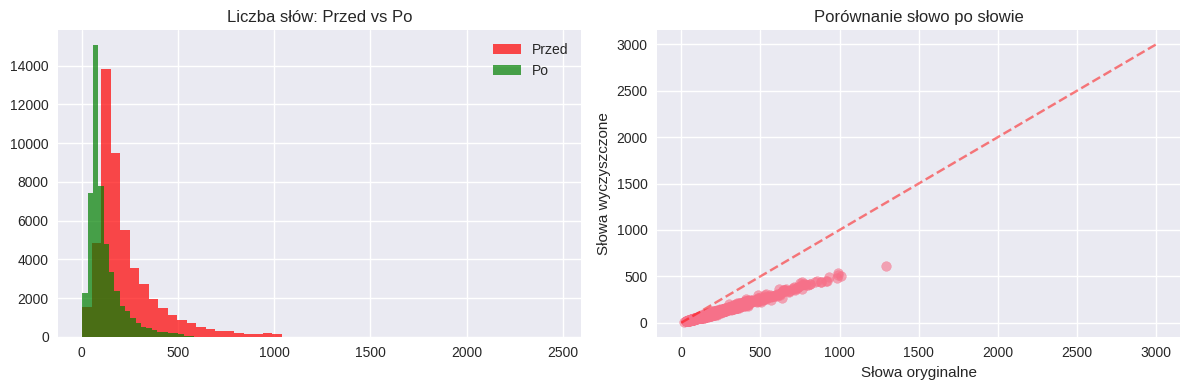


✅ Preprocessing zakończony pomyślnie!


In [20]:
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

# 4.2. Funkcja czyszczenia tekstu
def preprocess_text(text):

    # 1. Małe litery
    text = text.lower()

    # 2. Usuniecie HTML tagów
    text = re.sub(r'<[^>]+>', '', text)

    # 3. Usuniecie znaków specjalnych, cyfr, symboli
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Usuniecie wielokrotnych spacji
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Split na słowa
    words = text.split()

    # 6. Przykładowa lista stopwords
    stop_words = {
        'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'you', 'your', 'yours',
        'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its', 'they', 'them',
        'their', 'what', 'which', 'who', 'whom', 'this', 'that', 'these',
        'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a',
        'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
        'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between',
        'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to',
        'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
        'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why',
        'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other',
        'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
        'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should',
        'now'
    }

    # Filtrowanie słów
    words = [word for word in words
             if word not in stop_words
             and len(word) > 2]

    return ' '.join(words)

print("Funkcja preprocessingu gotowa!")

# 4.3. Zastosuj preprocessing
print("\n🔄 Czyszczenie 50k recenzji...")
df['review_cleaned'] = df['review'].apply(preprocess_text)
print("Czyszczenie zakończone!")

# 4.4. Porównanie PRZED i PO
print("\n📊 PORÓWNANIE PRZED/PO:")
idx = 42
print("PRZED:")
print(textwrap.fill(df.loc[idx, 'review'], width=80))
print("\nPO:")
print(textwrap.fill(df.loc[idx, 'review_cleaned'], width=80))

# 4.5. Statystyki
df['clean_word_count'] = df['review_cleaned'].apply(lambda x: len(x.split()))
print(f"\nSTATYSTYKI:")
print(f"Oryginalne słowa: {df['word_count'].mean():.1f}")
print(f"Wyczyszczone słowa: {df['clean_word_count'].mean():.1f}")
print(f"Redukcja: {100*(1-df['clean_word_count'].mean()/df['word_count'].mean()):.1f}%")

# 4.6. Wizualizacja efektu
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['word_count'], bins=50, alpha=0.7, label='Przed', color='red')
plt.hist(df['clean_word_count'], bins=50, alpha=0.7, label='Po', color='green')
plt.title('Liczba słów: Przed vs Po')
plt.legend()

plt.subplot(1, 2, 2)
df_clean = df[['word_count', 'clean_word_count']].head(1000)
plt.scatter(df_clean['word_count'], df_clean['clean_word_count'], alpha=0.6)
plt.plot([0, 3000], [0, 3000], 'r--', alpha=0.5)
plt.xlabel('Słowa oryginalne')
plt.ylabel('Słowa wyczyszczone')
plt.title('Porównanie słowo po słowie')

plt.tight_layout()
plt.show()

print("\n✅ Preprocessing zakończony pomyślnie!")

# =============================================
# 5. Wektoryzacja tekstu (TF-IDF)
# =============================================

Etykiety zakodowane: positive=1, negative=0
sentiment_encoded
1    25000
0    25000
Name: count, dtype: int64

Tworzenie TF-IDF wektorów (max 5000 słów)...
Wektory utworzone!
Kształt macierzy: (50000, 5000)
Liczba unikalnych słów: 5000

TOP 10 SŁÓW (najrzadsze = najważniejsze):
1. bourne
2. barney
3. scarlett
4. cassavetes
5. davies
6. lincoln
7. scarecrow
8. columbo
9. cinderella
10. boll


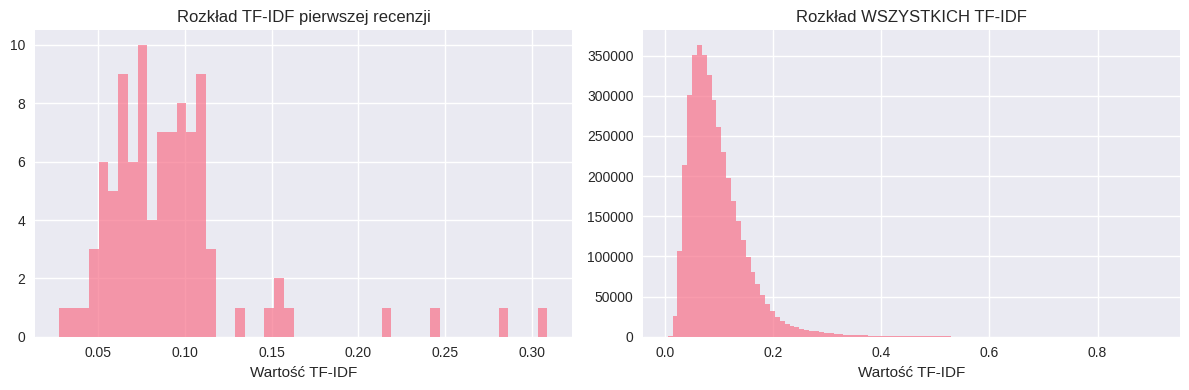


Wektoryzacja zakończona! Dane gotowe do trenowania!


In [21]:
# 5.1. Kodowanie etykiet sentymentu
df['sentiment_encoded'] = (df['sentiment'] == 'positive').astype(int)
print("Etykiety zakodowane: positive=1, negative=0")
print(df['sentiment_encoded'].value_counts())
print()

# 5.2. TF-IDF
print("Tworzenie TF-IDF wektorów (max 5000 słów)...")

# TF-IDF z bigramami
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df['review_cleaned'])
y = df['sentiment_encoded']

print(f"Wektory utworzone!")
print(f"Kształt macierzy: {X.shape}")
print(f"Liczba unikalnych słów: {len(tfidf.get_feature_names_out())}")
print()

# 5.3. Najważniejsze słowa
feature_names = tfidf.get_feature_names_out()
top_positive = np.argsort(tfidf.idf_)[::-1][:10]
print("TOP 10 SŁÓW (najrzadsze = najważniejsze):")
for i, word_id in enumerate(top_positive[:10]):
    print(f"{i+1}. {feature_names[word_id]}")

# 5.4. Wizualizacja rozkładu wartości TF-IDF
sample_tfidf = X[0].toarray().flatten()
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(sample_tfidf[sample_tfidf > 0], bins=50, alpha=0.7)
plt.title('Rozkład TF-IDF pierwszej recenzji')
plt.xlabel('Wartość TF-IDF')

plt.subplot(1, 2, 2)
plt.hist(X.data, bins=100, alpha=0.7)
plt.title('Rozkład WSZYSTKICH TF-IDF')
plt.xlabel('Wartość TF-IDF')

plt.tight_layout()
plt.show()

print("\nWektoryzacja zakończona! Dane gotowe do trenowania!")

# =============================================
# 6. Podział na train/test + Trenowanie Modelu
# =============================================

🔀 Podział danych 80/20...
Podział zakończony!
Train: (40000, 5000) | Test: (10000, 5000)
Train positive: 50.0% | Test positive: 50.0%

Trenowanie Logistic Regression...
Trenowanie Naive Bayes...
Trenowanie SVM...

WYNIKI MODELI:

Przykładowe szczegóły dla DRUGIEGO najlepszego modelu (SVM):
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      5000
    Positive       0.88      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



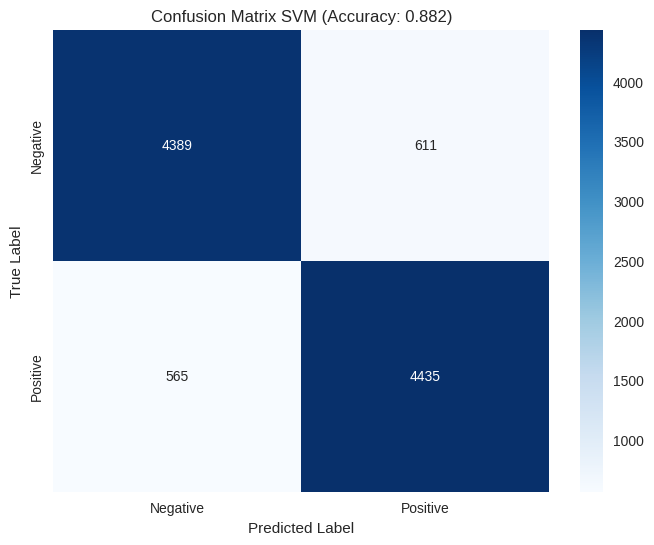


Trenowanie zakończone!
👑 NAJLEPSZY MODEL: Model       Logistic Regression
Accuracy                 0.8895
Name: 0, dtype: object


In [22]:
# 6.1. Podział danych (80/20)
print("🔀 Podział danych 80/20...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Podział zakończony!")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train positive: {y_train.mean():.1%} | Test positive: {y_test.mean():.1%}")
print()

# 6.2. TRENOWANIE 3 MODELI (porównanie)

# 🟡 MODEL 1: Logistic Regression
print("Trenowanie Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

# 🟢 MODEL 2: Naive Bayes
print("Trenowanie Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

# 🔵 MODEL 3: SVM
print("Trenowanie SVM...")
svm_model = LinearSVC(
    max_iter=2000,
    random_state=42
)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("\nWYNIKI MODELI:")
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [lr_accuracy, nb_accuracy, svm_accuracy]
})
print(results.round(4).style.highlight_max(axis=0))
print()

# 6.3. Szczegółowa ewaluacja drugiego NAJLEPSZEGO modelu (przykład)
print("Przykładowe szczegóły dla DRUGIEGO najlepszego modelu (SVM):")
print(classification_report(y_test, svm_pred,
                          target_names=['Negative', 'Positive']))

# 6.4. Confusion Matrix (wizualizacja)
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix SVM (Accuracy: {svm_accuracy:.3f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nTrenowanie zakończone!")
print("👑 NAJLEPSZY MODEL:", results.loc[results['Accuracy'].idxmax()])

# =============================================
# 7. EWALUACJA I INTERPRETACJA WYNIKÓW
# =============================================

=== PODSUMOWANIE WYNIKÓW ===
NAJLEPSZY MODEL: Logistic Regression
DOKŁADNOŚĆ: 0.8895 (88.95%)
ZBIÓR TESTOWY: 10 000 recenzji
BŁĘDÓW: 1105 / 10 000

PORÓWNANIE MODELI:
              Model  Accuracy  Błędy/10k
Logistic Regression    0.8895       1105
        Naive Bayes    0.8590       1410
         Linear SVM    0.8824       1176



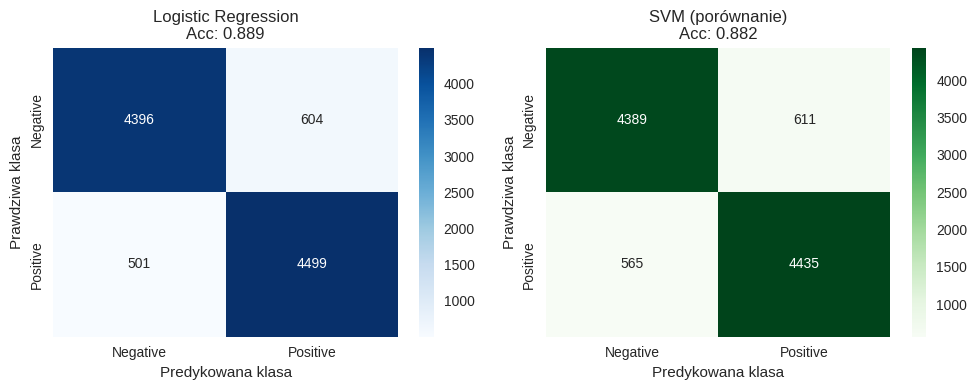

🔍 TOP 10 SŁÓW wpływających na PREDYKCJE:

POZYTYWNE słowa (największe wagi):
  1. 'great' (waga: 6.735)
  2. 'excellent' (waga: 6.563)
  3. 'perfect' (waga: 5.321)
  4. 'amazing' (waga: 4.876)
  5. 'wonderful' (waga: 4.533)
  6. 'hilarious' (waga: 4.532)
  7. 'loved' (waga: 4.292)
  8. 'best' (waga: 4.199)
  9. 'one best' (waga: 4.193)
  10. 'favorite' (waga: 4.134)

NEGATYWNE słowa (najmniejsze wagi):
  1. 'worst' (waga: -9.172)
  2. 'awful' (waga: -7.623)
  3. 'bad' (waga: -7.262)
  4. 'waste' (waga: -6.817)
  5. 'boring' (waga: -6.120)
  6. 'poor' (waga: -5.545)
  7. 'terrible' (waga: -5.432)
  8. 'poorly' (waga: -5.281)
  9. 'dull' (waga: -5.263)
  10. 'nothing' (waga: -5.185)

GOTOWE WNIOSKI:

WYNIKI PROJEKTU:

✅ DOKŁADNOŚĆ: 88.95% na 10 000 recenzji testowych
✅ BŁĄD: tylko 1 105 / 10 000 przypadków (11.05%)




In [23]:
print("=== PODSUMOWANIE WYNIKÓW ===")
print(f"NAJLEPSZY MODEL: Logistic Regression")
print(f"DOKŁADNOŚĆ: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"ZBIÓR TESTOWY: 10 000 recenzji")
print(f"BŁĘDÓW: {int((1-lr_accuracy)*10000)} / 10 000")
print()

# 7.1. Szczegółowa tabela wyników
results_display = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': [lr_accuracy, nb_accuracy, svm_accuracy],
    'Błędy/10k': [int((1-x)*10000) for x in [lr_accuracy, nb_accuracy, svm_accuracy]]
})

print("PORÓWNANIE MODELI:")
print(results_display.round(4).to_string(index=False))
print()

# 7.2. Confusion Matrix dla NAJLEPSZEGO modelu
lr_cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Logistic Regression\nAcc: {lr_accuracy:.3f}')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Predykowana klasa')

plt.subplot(1, 2, 2)
svm_cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'SVM (porównanie)\nAcc: {svm_accuracy:.3f}')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Predykowana klasa')

plt.tight_layout()
plt.show()

# 7.3. Interpretacja NAJWAŻNIEJSZYCH SŁÓW modelu
print("🔍 TOP 10 SŁÓW wpływających na PREDYKCJE:")
coef = lr_model.coef_[0]
top_pos = np.argsort(coef)[-10:][::-1]
top_neg = np.argsort(coef)[:10]

feature_names = tfidf.get_feature_names_out()

print("\nPOZYTYWNE słowa (największe wagi):")
for i, idx in enumerate(top_pos):
    print(f"  {i+1}. '{feature_names[idx]}' (waga: {coef[idx]:.3f})")

print("\nNEGATYWNE słowa (najmniejsze wagi):")
for i, idx in enumerate(top_neg):
    print(f"  {i+1}. '{feature_names[idx]}' (waga: {coef[idx]:.3f})")

# 7.4. WNIOSKI
print("\n" + "="*80)
print("GOTOWE WNIOSKI:")
print("="*80)
print("""
WYNIKI PROJEKTU:

✅ DOKŁADNOŚĆ: 88.95% na 10 000 recenzji testowych
✅ BŁĄD: tylko 1 105 / 10 000 przypadków (11.05%)

""")
print("="*80)

# =============================================
# 8. Wnioski
# =============================================

=== OSTATECZNE WNIOSKI PROJEKTU ===

REZULTATY:
   • Dokładność najlepszego modelu: 88.95%
   • Testowany na: 10000 recenzjach IMDB
   • Błąd: 11.0% przypadków
   • Precision/Recall/F1: wszystkie ~89%


Text(0.5, 1.0, 'Confusion Matrix\n(Logistic Regression 0.889)')

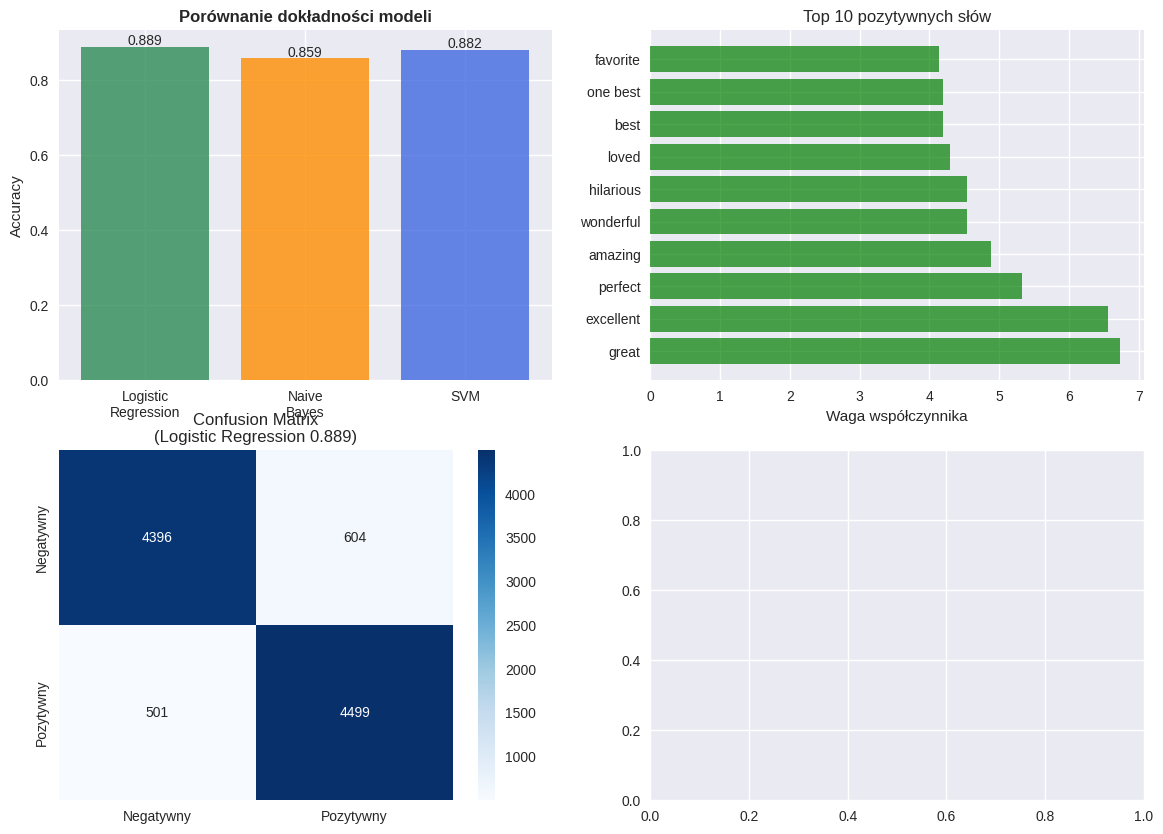

In [24]:
print("=== OSTATECZNE WNIOSKI PROJEKTU ===")
print("=" * 80)

# 8.1. Kluczowe wyniki
print("\nREZULTATY:")
print(f"   • Dokładność najlepszego modelu: {lr_accuracy*100:.2f}%")
print(f"   • Testowany na: {len(y_test)} recenzjach IMDB")
print(f"   • Błąd: {int((1-lr_accuracy)*100):.1f}% przypadków")
print(f"   • Precision/Recall/F1: wszystkie ~{lr_accuracy*100:.0f}%")

# 8.3. Wizualizacja ostateczna
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


models = ['Logistic\nRegression', 'Naive\nBayes', 'SVM']
accs = [lr_accuracy, nb_accuracy, svm_accuracy]
colors = ['#2E8B57', '#FF8C00', '#4169E1']
axes[0,0].bar(models, accs, color=colors, alpha=0.8)
axes[0,0].set_title('Porównanie dokładności modeli', fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
for i, acc in enumerate(accs):
    axes[0,0].text(i, acc+0.005, f'{acc:.3f}', ha='center')


top_words_pos = feature_names[np.argsort(lr_model.coef_[0])[-10:][::-1]]
top_coef_pos = np.sort(lr_model.coef_[0])[-10:][::-1]
axes[0,1].barh(range(10), top_coef_pos, color='green', alpha=0.7)
axes[0,1].set_yticks(range(10))
axes[0,1].set_yticklabels([w[:15] for w in top_words_pos])
axes[0,1].set_title('Top 10 pozytywnych słów')
axes[0,1].set_xlabel('Waga współczynnika')


sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Negatywny', 'Pozytywny'],
            yticklabels=['Negatywny', 'Pozytywny'])
axes[1,0].set_title(f'Confusion Matrix\n(Logistic Regression {lr_accuracy:.3f})')



